## Time series forecasting of electricity consumption (Part 1)

In this notebook I work on Part 1 of the exam: forecasting the electricity consumption of one building at a 15-minute resolution. The goal is to train and compare several models (from simple baselines to classical time-series and machine-learning models), select the best one using a validation day, and then produce a 96-step forecast for 2010-02-19 to be delivered in an Excel file.

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error

HORIZON = 96          
FREQ = "15min"

df = pd.read_excel("../data/Elec-train.xlsx")
df


,Timestamp,Power (kW),Temp (C°)
0,2010-01-01 01:15:00,165.1,10.555556
1,1/1/2010 1:30,151.6,10.555556
2,1/1/2010 1:45,146.9,10.555556
3,1/1/2010 2:00,153.7,10.555556
4,1/1/2010 2:15,153.8,10.555556
...,...,...,...
4790,2/19/2010 22:45,NaN,11.111111
4791,2/19/2010 23:00,NaN,11.111111
4792,2/19/2010 23:15,NaN,10.000000
4793,2/19/2010 23:30,NaN,10.000000


In [70]:
df.shape

(4795, 3)

In [71]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4795 entries, 0 to 4794
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Timestamp   4795 non-null   datetime64[us]
 1   Power (kW)  4699 non-null   float64       
 2   Temp (C°)   4795 non-null   float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 112.5 KB


In [73]:
df.describe()

,Timestamp,Power (kW),Temp (C°)
count,4795,4699.000000,4795.000000
mean,2010-01-26 00:30:00,231.225984,10.931989
min,2010-01-01 01:15:00,0.000000,3.888889
25%,2010-01-13 12:52:30,163.100000,8.888889
50%,2010-01-26 00:30:00,253.600000,11.111111
75%,2010-02-07 12:07:30,277.700000,12.777778
max,2010-02-19 23:45:00,355.100000,19.444444
std,NaN,58.667173,2.717175


## Visual exploration of the time series

I first sort the data by timestamp, set the timestamp as the index, and plot both the power consumption and outdoor temperature over time. This helps me visually inspect trends, daily patterns, and any obvious anomalies before building forecasting models.

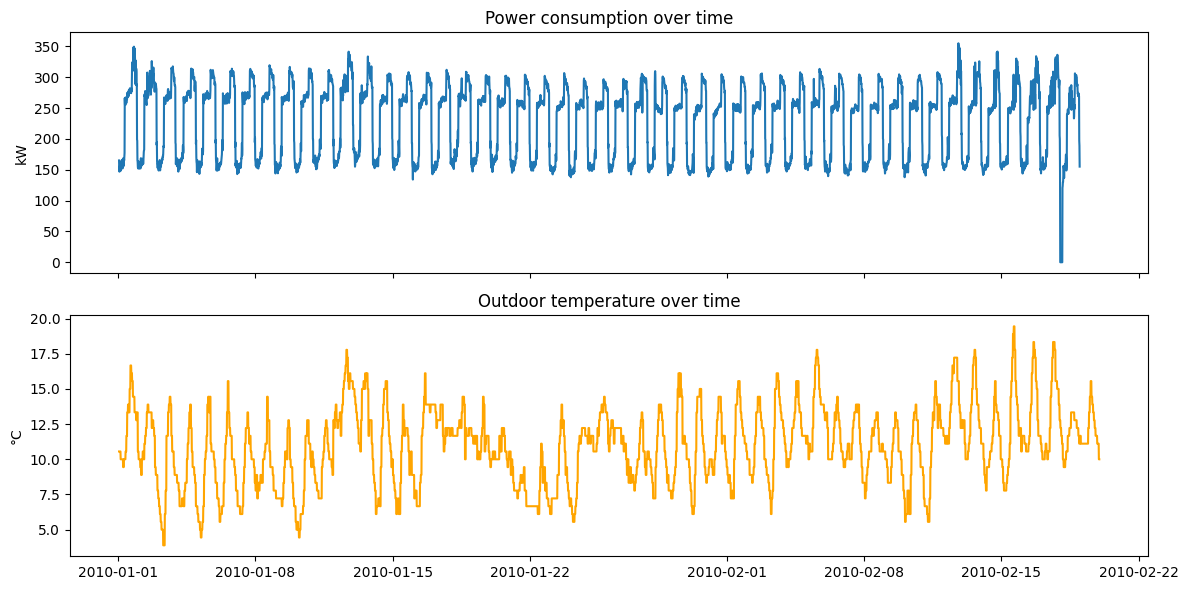

In [74]:
# Set timestamp as index (if not already) and plot the series

# Make sure the dataframe is sorted by time and use Timestamp as index
df = df.sort_values("Timestamp").set_index("Timestamp")

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(df.index, df["Power (kW)"])
axes[0].set_title("Power consumption over time")
axes[0].set_ylabel("kW")

axes[1].plot(df.index, df["Temp (C°)"], color="orange")
axes[1].set_title("Outdoor temperature over time")
axes[1].set_ylabel("°C")

plt.tight_layout()
plt.show()

## Separate known data and forecast horizon

Here I split the dataframe into two parts: `df_known`, which contains all timestamps where the power consumption is observed (up to 2010-02-18), and `df_forecast`, which contains the timestamps for 2010-02-19 where the power is missing. The second part is exactly the 96-step horizon I need to forecast.

In [75]:
# Separate known power values (training data) and rows to forecast (where power is NaN)

# Rows where we already know the power consumption (up to 2010-02-18)
df_known = df[~df["Power (kW)"].isna()].copy()

# Rows for 2010-02-19 where power is missing but temperature is available
df_forecast = df[df["Power (kW)"].isna()].copy()

print("Known data shape:", df_known.shape)
print("Forecast horizon rows (should be 96):", df_forecast.shape)

df_known.tail(), df_forecast.head()

Known data shape: (4699, 2)
Forecast horizon rows (should be 96): (96, 2)


(                     Power (kW)  Temp (C°)
 Timestamp                                 
 2010-02-18 22:45:00       268.6  11.666667
 2010-02-18 23:00:00       269.2  11.666667
 2010-02-18 23:15:00       197.1  11.111111
 2010-02-18 23:30:00       188.9  11.111111
 2010-02-18 23:45:00       155.1  11.111111,
                      Power (kW)  Temp (C°)
 Timestamp                                 
 2010-02-19 00:00:00         NaN  11.111111
 2010-02-19 00:15:00         NaN  11.666667
 2010-02-19 00:30:00         NaN  11.666667
 2010-02-19 00:45:00         NaN  11.666667
 2010-02-19 01:00:00         NaN  11.666667)

## Train/validation split (last day as validation)

To mimic the exam setup, I keep the last known day (96 points) as a validation set and use the earlier part of the series for training. The training set is used to fit the models, and the validation day is used to measure how well they can forecast a full day ahead.

In [76]:
# Create a univariate training / validation split for Power (kW)

# Use only the known part of the series
y = df_known["Power (kW)"]

# We want to emulate a 1-day-ahead forecast (96 steps of 15 minutes)
HORIZON = 96

# Use the last 96 known points as a validation set
y_train = y.iloc[:-HORIZON]
y_val = y.iloc[-HORIZON:]

print("Train length:", len(y_train))
print("Validation length:", len(y_val))

y_train.tail(), y_val.head()

Train length: 4603
Validation length: 96


(Timestamp
 2010-02-17 22:45:00    288.2
 2010-02-17 23:00:00    295.2
 2010-02-17 23:15:00    205.4
 2010-02-17 23:30:00    200.0
 2010-02-17 23:45:00    145.3
 Name: Power (kW), dtype: float64,
 Timestamp
 2010-02-18 00:00:00    0.0
 2010-02-18 00:15:00    0.0
 2010-02-18 00:30:00    0.0
 2010-02-18 00:45:00    0.0
 2010-02-18 01:00:00    0.0
 Name: Power (kW), dtype: float64)

In [77]:
# Helper function to evaluate forecasts
from math import sqrt


def evaluate_forecast(y_true, y_pred, model_name="model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = sqrt(mean_squared_error(y_true, y_pred))
    print(f"{model_name}: MAE={mae:.3f}, RMSE={rmse:.3f}")
    return {"model": model_name, "MAE": mae, "RMSE": rmse}

## Baseline forecasting models

Before trying more complex models, I build two simple baselines: a naive forecast that repeats the last observed value, and a seasonal naive forecast that copies the values from the previous day (96 steps back). These give reference error levels that any more advanced method should beat.

In [78]:
# Baseline models: naive and seasonal naive

results_baseline = []

# 1) Naive forecast: repeat the last observed value
y_pred_naive = np.repeat(y_train.iloc[-1], HORIZON)
metrics_naive = evaluate_forecast(y_val, y_pred_naive, "Naive (last value)")
results_baseline.append(metrics_naive)

# 2) Seasonal naive: use the values from the previous day (96 steps back)
#    This assumes a strong daily pattern
y_pred_seasonal = y_train.iloc[-HORIZON:].values
metrics_seasonal = evaluate_forecast(y_val, y_pred_seasonal, "Seasonal naive (last day)")
results_baseline.append(metrics_seasonal)

Naive (last value): MAE=97.291, RMSE=110.314
Seasonal naive (last day): MAE=32.907, RMSE=56.205


In [79]:
# Exponential Smoothing (ETS) model with daily seasonality
from statsmodels.tsa.holtwinters import ExponentialSmoothing

ets_model = ExponentialSmoothing(
    y_train,
    trend=None,
    seasonal="add",          # additive seasonal pattern
    seasonal_periods=HORIZON,  # 96 steps per day
).fit(optimized=True)

y_pred_ets = ets_model.forecast(HORIZON)
metrics_ets = evaluate_forecast(y_val, y_pred_ets, "ETS (additive seasonal)")

c:\Users\njaya\Time_Series_Analysis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)


ETS (additive seasonal): MAE=25.512, RMSE=52.104


c:\Users\njaya\Time_Series_Analysis\venv\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


## Classical time series models (ETS and SARIMA)

After the baselines, I fit two standard time series models: an Exponential Smoothing (ETS) model with daily seasonality (period 96) and a seasonal ARIMA (SARIMA) model. Both are trained on the training part of the series and used to forecast the 96 validation points so I can compare them to the other approaches.

In [80]:
# SARIMA model (simple specification as a starting point)
import statsmodels.api as sm

sarima_order = (1, 0, 0)              # (p, d, q)
seasonal_order = (1, 1, 0, HORIZON)   # (P, D, Q, s) with s = 96

sarima_model = sm.tsa.statespace.SARIMAX(
    y_train,
    order=sarima_order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

y_pred_sarima = sarima_model.forecast(HORIZON)
metrics_sarima = evaluate_forecast(y_val, y_pred_sarima, "SARIMA")

c:\Users\njaya\Time_Series_Analysis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)
c:\Users\njaya\Time_Series_Analysis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)


SARIMA: MAE=30.281, RMSE=54.613


## Feature engineering for machine-learning models

To use tree-based and neural network models, I transform the time series into a supervised learning dataset. I create time-based features (hour of day, day of week, weekend), lag features (previous 1, 2, and 96 steps), and a 96-step rolling mean, and then build training and validation feature matrices aligned with the same validation period used for the time-series models.

In [ ]:
# Feature engineering for machine-learning models (Random Forest, SVR, simple NN)

# Start from the full dataframe so that we can also build features for 2010-02-19
df_features = df.copy()

# Time-based calendar features
df_features["hour"] = df_features.index.hour
df_features["dayofweek"] = df_features.index.dayofweek
df_features["is_weekend"] = df_features["dayofweek"].isin([5, 6]).astype(int)

# Lag features (previous 1, 2 and 96 steps)
for lag in [1, 2, 96]:
    df_features[f"lag_{lag}"] = df_features["Power (kW)"].shift(lag)

# Rolling mean of the last day (96 previous points)
df_features["rolling_mean_96"] = (
    df_features["Power (kW)"].shift(1).rolling(window=96).mean()
)

# Keep only rows where the target is known and features are not NaN
train_mask_ml = ~df_features["Power (kW)"].isna()
data_ml_train = df_features.loc[train_mask_ml].dropna()

feature_cols = [
    "Temp (C°)",
    "hour",
    "dayofweek",
    "is_weekend",
    "lag_1",
    "lag_2",
    "lag_96",
    "rolling_mean_96",
]

X_all = data_ml_train[feature_cols]
y_all = data_ml_train["Power (kW)"]

# Use the same validation period as before (the last 96 known timestamps)
val_index = y_val.index

X_train = X_all.loc[X_all.index.difference(val_index)]
y_train_ml = y_all.loc[X_train.index]

X_val = X_all.loc[val_index]
y_val_ml = y_all.loc[val_index]

print("ML train shape:", X_train.shape)
print("ML validation shape:", X_val.shape)

ML train shape: (4507, 8)
ML validation shape: (96, 8)


## Machine-learning models (Random Forest, SVR, MLP)

Using the engineered features, I now fit several regression models from scikit-learn: a Random Forest, a Support Vector Regressor (SVR) with RBF kernel, and a simple feed-forward neural network (MLPRegressor). Each model predicts the power consumption for the validation day, and I evaluate them with the same error metrics.

In [ ]:
# Machine-learning models: Random Forest, SVR, simple neural network (MLP)

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

results_ml = []

# Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train_ml)
y_pred_rf = rf.predict(X_val)
results_ml.append(evaluate_forecast(y_val_ml, y_pred_rf, "Random Forest"))

# Support Vector Regression with RBF kernel
svr = make_pipeline(
    StandardScaler(),
    SVR(kernel="rbf", C=10.0, epsilon=0.1),
)
svr.fit(X_train, y_train_ml)
y_pred_svr = svr.predict(X_val)
results_ml.append(evaluate_forecast(y_val_ml, y_pred_svr, "SVR (RBF kernel)"))

# Simple feed-forward neural network (Multi-layer Perceptron)
mlp = make_pipeline(
    StandardScaler(),
    MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=300,
        random_state=42,
    ),
)
mlp.fit(X_train, y_train_ml)
y_pred_mlp = mlp.predict(X_val)
results_ml.append(evaluate_forecast(y_val_ml, y_pred_mlp, "MLPRegressor"))

Random Forest: MAE=26.088, RMSE=52.488
SVR (RBF kernel): MAE=35.568, RMSE=70.548
MLPRegressor: MAE=37.732, RMSE=66.946


c:\Users\njaya\Time_Series_Analysis\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


## Model comparison on validation day

Here I collect the errors (MAE and RMSE) of all models on the last known day (96 points). This allows me to compare naive baselines, classical time series models, and machine-learning models in a fair way and choose the best-performing approach.

In [ ]:
# Compare all model performances on the validation day

all_results = [
    metrics_naive,
    metrics_seasonal,
    metrics_ets,
    metrics_sarima,
    *results_ml,
]

results_df = pd.DataFrame(all_results).set_index("model").sort_values("RMSE")
results_df

,MAE,RMSE
model,,
ETS (additive seasonal),25.512377,52.104452
Random Forest,26.088292,52.487592
SARIMA,30.280665,54.612858
Seasonal naive (last day),32.907292,56.205394
MLPRegressor,37.731707,66.945894
SVR (RBF kernel),35.567652,70.548361
Naive (last value),97.290625,110.314161


## Final forecast and Excel export

In this step I take the model that performed best on the validation day, refit/keep it on the training data, and use it to predict the 96 values for 2010-02-19. I then save these 96 forecasts into an Excel file with exactly one column and 96 rows, as required by the exam statement.

In [ ]:
# Train a Random Forest model on all known data and forecast 2010-02-19

from sklearn.ensemble import RandomForestRegressor

# Rebuild features here so this cell can be run on a fresh kernel
# (it mirrors the earlier feature engineering step).
df_features = df.copy()

df_features["hour"] = df_features.index.hour
df_features["dayofweek"] = df_features.index.dayofweek
df_features["is_weekend"] = df_features["dayofweek"].isin([5, 6]).astype(int)

for lag in [1, 2, 96]:
    df_features[f"lag_{lag}"] = df_features["Power (kW)"].shift(lag)

df_features["rolling_mean_96"] = (
    df_features["Power (kW)"].shift(1).rolling(window=96).mean()
)

feature_cols = [
    "Temp (C°)",
    "hour",
    "dayofweek",
    "is_weekend",
    "lag_1",
    "lag_2",
    "lag_96",
    "rolling_mean_96",
]

# Use all rows where the target is known and features are complete
train_mask_ml = ~df_features["Power (kW)"].isna()
data_ml_train = df_features.loc[train_mask_ml].dropna()

X_all = data_ml_train[feature_cols]
y_all = data_ml_train["Power (kW)"]

rf_final = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)
rf_final.fit(X_all, y_all)

# Rows for 2010-02-19 where power is missing but temperature is available
df_forecast = df[df["Power (kW)"].isna()].copy()
forecast_index = df_forecast.index
X_forecast = df_features.loc[forecast_index, feature_cols]

print("Forecast feature shape:", X_forecast.shape)

y_forecast = rf_final.predict(X_forecast)

# Put forecast into a DataFrame with exactly 1 column and 96 rows
forecast_df = pd.DataFrame(y_forecast, columns=["Power_forecast_kW"])

# Save to Excel – change the file name to your own name
output_path = Path("../data/YourName.xlsx")
forecast_df.to_excel(output_path, index=False)

output_path, forecast_df.head()

Forecast feature shape: (96, 8)


(WindowsPath('../data/YourName.xlsx'),
    Power_forecast_kW
 0           152.4485
 1           201.6420
 2           200.6060
 3           200.6060
 4           200.4860)